### Limpeza, transformação e Análise de Dados com Pandas

**O que é e quando usar o Pandas?**

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%reload_ext watermark
%watermark -a "Leonardo da Silva Neves"

Author: Leonardo da Silva Neves



In [3]:
%watermark --iversions

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3



### 1. Pandas e Estruturas de Dados - Séries e DataFrame

Começando criando as estruturas de dados fundamentais: Série e DataFrame.

No Pandas, um Série é uma estrutura unidimensional, parecida com uma coluna de umam tabela: contém um sequência de valores com um índice associado. Já um DataFrame é um estrutura bidimensional, semelhante a uma planilha, tabela ou matriz, formada por várias colunas (que são, internamente, Séries alinhadas pelo mesmo índice).

In [4]:
# Criando um Série (uma única coluna)
s = pd.Series([10, 20, 30, 40, 50], name = 'Valores') 

In [5]:
type(s)

pandas.core.series.Series

In [6]:
print("\n---Exemplo de Séries ---\n")
print(s)
print("\n")


---Exemplo de Séries ---

0    10
1    20
2    30
3    40
4    50
Name: Valores, dtype: int64




In [7]:
# Criando um dicionário em Python
dados = {
    'Nome': ['Ana', 'Bruno', 'Fabiana', 'Ronaldo', 'Eliana', 'Matias'],
    'Idade': [28, 34, 29, 17, None, 78],
    'Cidade': ['Blumenau', 'São Paulo', 'Blumenau', 'São Paulo', 'Salvador', 'São Paulo'],
    'Salario': [None, 7500, 6500, 9300, 8100, 15400]}

In [8]:
type(dados)

dict

In [9]:
print(dados)

{'Nome': ['Ana', 'Bruno', 'Fabiana', 'Ronaldo', 'Eliana', 'Matias'], 'Idade': [28, 34, 29, 17, None, 78], 'Cidade': ['Blumenau', 'São Paulo', 'Blumenau', 'São Paulo', 'Salvador', 'São Paulo'], 'Salario': [None, 7500, 6500, 9300, 8100, 15400]}


In [10]:
# Convertendo um dicionário em um DataFrame Pandas

df = pd.DataFrame(dados)

In [11]:
print("\n--- Exemplo de DataFrame ---\n")
print(df)


--- Exemplo de DataFrame ---

      Nome  Idade     Cidade  Salario
0      Ana   28.0   Blumenau      NaN
1    Bruno   34.0  São Paulo   7500.0
2  Fabiana   29.0   Blumenau   6500.0
3  Ronaldo   17.0  São Paulo   9300.0
4   Eliana    NaN   Salvador   8100.0
5   Matias   78.0  São Paulo  15400.0


In [12]:
type(df)

pandas.core.frame.DataFrame

### 2. Leitura e Escrita de Dados no Formato .CSV

Pandas torna muito fácil salvar seu DataFrame em um arquivo .csv e carregá-lo de volta.

In [13]:
# Escrevendo (salvando) o DataFrame em um arquivo .csv
# o index=False evita que o índice do DataFrame seja salvo como uma coluno no CSV
df.to_csv('dados_funcionarios_sem_indice.csv', index=False, encoding ='utf-8')

In [14]:
# Escrevendo (salvado) o DataFrame em outro arquivo .csv
# o index=True (valor padrão) inclui o índice no DataFrame como uma coluna no CSV
df.to_csv('dados_funcionarios_com_indice.csv', index=True, encoding = 'utf-8')

In [15]:
# Lendo dados de um arquivo .csv para um novo DataFrame
df_1 = pd.read_csv('dados_funcionarios_sem_indice.csv')

In [16]:
# Visualizando as primeiras linhas
df_1.head()

,Nome,Idade,Cidade,Salario
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6500.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0


In [17]:
# Lendo dados de um arquivo .csv para um novo DataFrame
df_2 = pd.read_csv('dados_funcionarios_com_indice.csv')

In [18]:
# Visualizar as primeiras linhas
df_2.head()

,Unnamed: 0,Nome,Idade,Cidade,Salario
0,0,Ana,28.0,Blumenau,NaN
1,1,Bruno,34.0,São Paulo,7500.0
2,2,Fabiana,29.0,Blumenau,6500.0
3,3,Ronaldo,17.0,São Paulo,9300.0
4,4,Eliana,NaN,Salvador,8100.0


In [19]:
# Deletando a coluna de índice 0
df_2 = df_2.drop(df_2.columns[0], axis=1)

In [20]:
# Visualizando as primeiras linhas
df_2.head(6)

,Nome,Idade,Cidade,Salario
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6500.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


### 3. Seleção e Indexação com Pandas

Existem várias maneiras de selecionar dados de um DataFrame. As mais comuns são loc (baseado em rótulo) iloc (baseado em posição/índice númerico)

In [21]:
# Visualizando as primeiras linhas
df.head()

,Nome,Idade,Cidade,Salario
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6500.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0


In [22]:
# Selecionando um única coluna (retorna uma Series)
nomes = df['Nome']
print("\n--- Selecionando a coluna 'Nome' ---\n")
print(nomes)
print("\n")


--- Selecionando a coluna 'Nome' ---

0        Ana
1      Bruno
2    Fabiana
3    Ronaldo
4     Eliana
5     Matias
Name: Nome, dtype: object




In [23]:
type(nomes)

pandas.core.series.Series

In [24]:
# Selecionando multiplas colunas (retorna um DataFrame)
info_pessoal = df[['Nome', 'Idade']]
print("\n--- Selecionando as colunas 'Nome' e 'Idade' ---\n")
print(info_pessoal)
print("\n")


--- Selecionando as colunas 'Nome' e 'Idade' ---

      Nome  Idade
0      Ana   28.0
1    Bruno   34.0
2  Fabiana   29.0
3  Ronaldo   17.0
4   Eliana    NaN
5   Matias   78.0




In [25]:
type(info_pessoal)

pandas.core.frame.DataFrame

In [26]:
# Usando .loc para selecionar pela linha (rótulo/índice 1) e coluna 'Nome')
nome = df.loc[1, 'Nome']
print(f"\n--- Selecionando com o .loc[1, 'Nome'] ---\n{nome}\n")


--- Selecionando com o .loc[1, 'Nome'] ---
Bruno



In [27]:
# Usando .iloc para selecionar pela posição da linha (linha 2) e da coluna (coluna 3)
salario_fabiana = df.iloc[2, 3]
print(f"\n--- Selecionando com .iloc[2,3] ---\n{salario_fabiana}\n")


--- Selecionando com .iloc[2,3] ---
6500.0



In [28]:
# Visualizando o DataFrame
df.head(6)

,Nome,Idade,Cidade,Salario
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6500.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [29]:
# Selecionando um intervalo de linhas
primeiras_tres_linhas = df.loc[0:2] # O final (2) é inclusivo com .loc
print("\n--- Selecionando as 3 primeiras linhas com .loc ---\n")
print(primeiras_tres_linhas)


--- Selecionando as 3 primeiras linhas com .loc ---

      Nome  Idade     Cidade  Salario
0      Ana   28.0   Blumenau      NaN
1    Bruno   34.0  São Paulo   7500.0
2  Fabiana   29.0   Blumenau   6500.0


### 4. Filtragem de Dados com Pandas

Você pode filtrar linhas com base em condições lógicas, de forma muito intuitiva, bem como usar colunas com índice.

In [30]:
# Convertendo a colunas zero em índice
df = df.set_index(df.columns[0])

In [31]:
# Visualizando
df.head(6)

,Idade,Cidade,Salario
Nome,,,
Ana,28.0,Blumenau,NaN
Bruno,34.0,São Paulo,7500.0
Fabiana,29.0,Blumenau,6500.0
Ronaldo,17.0,São Paulo,9300.0
Eliana,NaN,Salvador,8100.0
Matias,78.0,São Paulo,15400.0


In [32]:
# Filtrando usando label do índice (linha) e da Coluna
df.loc["Fabiana", "Salario"]

np.float64(6500.0)

In [33]:
# Aplicando um filtro de forma que retorne um DataFrame. Observe a diferença sutil na síntaxe.
df.loc[["Fabiana"], ["Salario"]]

,Salario
Nome,
Fabiana,6500.0


In [34]:
df = df.reset_index()

In [35]:
df.head()

,Nome,Idade,Cidade,Salario
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6500.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0


In [36]:
# Filtrando funcionários com idade superior a 30 anos
mais_30 = df[df['Idade']>30]
print("\n--- Funcionários com mais de 30 anos ---\n")
print(mais_30)
print("\n")


--- Funcionários com mais de 30 anos ---

     Nome  Idade     Cidade  Salario
1   Bruno   34.0  São Paulo   7500.0
5  Matias   78.0  São Paulo  15400.0




In [37]:
# Filtrando funcionários de São Paulo com salário acima de 6000
sp_salario = df[(df['Cidade'] == 'São Paulo') & (df['Salario']> 6000)]
print("\n--- Funcionários de São Paulo com salário > 6000 ---\n")
print(sp_salario)


--- Funcionários de São Paulo com salário > 6000 ---

      Nome  Idade     Cidade  Salario
1    Bruno   34.0  São Paulo   7500.0
3  Ronaldo   17.0  São Paulo   9300.0
5   Matias   78.0  São Paulo  15400.0


In [38]:
# Verificando quais células tem valores núlos
df.isnull()

,Nome,Idade,Cidade,Salario
0,False,False,False,True
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,True,False,False
5,False,False,False,False


In [39]:
# Verificando se há qualquer valor nulo em cada coluna
df.isnull().any()

Nome       False
Idade       True
Cidade     False
Salario     True
dtype: bool

In [40]:
# Retorna apenas as colunas que possuem pelo menos um valor nulo
df_colunas_com_nulos = df.loc[:, df.isnull().any()]

In [41]:
df_colunas_com_nulos.head()

,Idade,Salario
0,28.0,NaN
1,34.0,7500.0
2,29.0,6500.0
3,17.0,9300.0
4,NaN,8100.0


In [42]:
# Retorna apenas linhas com valores nulos
df_linhas_com_nulos = df[df.isnull().any(axis = 1)]

In [43]:
df_linhas_com_nulos.head()

,Nome,Idade,Cidade,Salario
0,Ana,28.0,Blumenau,NaN
4,Eliana,NaN,Salvador,8100.0


In [44]:
# Podemos ainda filtrar pela coluna e então verificar se há valores nulos
linhas_com_nulos_idade = df[df["Idade"].isnull()]

In [45]:
linhas_com_nulos_idade.head()

,Nome,Idade,Cidade,Salario
4,Eliana,NaN,Salvador,8100.0


### 5. Inspeção de DataFrames do Pandas

Podemos Inspecionar e resumir o dataframe de várias formas.

In [46]:
# Mostrar o número de linhas e colunas (formato)
print(f"\n--- Formato do DataFrame (.shape) ---\n{df.shape}")


--- Formato do DataFrame (.shape) ---
(6, 4)


In [47]:
# Mostrar as 3 primeiras linhas do DataFrame
print("\n--- As 3 primeiras linhas (.head(3)) ---\n")
print(df.head(3))
print("\n")


--- As 3 primeiras linhas (.head(3)) ---

      Nome  Idade     Cidade  Salario
0      Ana   28.0   Blumenau      NaN
1    Bruno   34.0  São Paulo   7500.0
2  Fabiana   29.0   Blumenau   6500.0




In [48]:
# Mostrar as duas últimas linhas do DataFrame
print("\n--- As duas últimas linhas (.tail(2)) ---\n")
print(df.tail(2))
print("\n")


--- As duas últimas linhas (.tail(2)) ---

     Nome  Idade     Cidade  Salario
4  Eliana    NaN   Salvador   8100.0
5  Matias   78.0  São Paulo  15400.0




In [49]:
# Fornece um resumo conciso do DataFrame (tipos de dados, valores não nulos, etc.)
# Observe a contagem de valores
print("\n--- Informações gerais (.info()) ---\n")
df.info()
print("\n")


--- Informações gerais (.info()) ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Nome     6 non-null      object 
 1   Idade    5 non-null      float64
 2   Cidade   6 non-null      object 
 3   Salario  5 non-null      float64
dtypes: float64(2), object(2)
memory usage: 324.0+ bytes




In [50]:
# Gera estatística descritivas de colunas numéricas
print("--- Estatísticas descritivas (.describe()) ---")
print(df.describe())
print("\n")

--- Estatísticas descritivas (.describe()) ---
           Idade       Salario
count   5.000000      5.000000
mean   37.200000   9360.000000
std    23.636836   3525.336863
min    17.000000   6500.000000
25%    28.000000   7500.000000
50%    29.000000   8100.000000
75%    34.000000   9300.000000
max    78.000000  15400.000000




In [51]:
print("\n--- Estatística descritivas (númericas e objetos) ---\n")
print(df.describe(include = 'all')) # inclui números, objetos e categorias


--- Estatística descritivas (númericas e objetos) ---

       Nome      Idade     Cidade       Salario
count     6   5.000000          6      5.000000
unique    6        NaN          3           NaN
top     Ana        NaN  São Paulo           NaN
freq      1        NaN          3           NaN
mean    NaN  37.200000        NaN   9360.000000
std     NaN  23.636836        NaN   3525.336863
min     NaN  17.000000        NaN   6500.000000
25%     NaN  28.000000        NaN   7500.000000
50%     NaN  29.000000        NaN   8100.000000
75%     NaN  34.000000        NaN   9300.000000
max     NaN  78.000000        NaN  15400.000000


In [52]:
df.describe(include = [object]) # só colunas do tipo object

,Nome,Cidade
count,6,6
unique,6,3
top,Ana,São Paulo
freq,1,3


In [53]:
df.describe(include = [np.number]) # só colunas numéricas (comportamento padrão)

,Idade,Salario
count,5.000000,5.000000
mean,37.200000,9360.000000
std,23.636836,3525.336863
min,17.000000,6500.000000
25%,28.000000,7500.000000
50%,29.000000,8100.000000
75%,34.000000,9300.000000
max,78.000000,15400.000000


### 6. Operações e Transformações de Dados com Pandas

Podemos facilmente criar novas colunas a partir de outras ou aplicar funções para modificar os dados. Fazemos isso com frequência em tarefas de engenharia de atributos em projetos de Ciência de Dados.

In [54]:
df.head(6)

,Nome,Idade,Cidade,Salario
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6500.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [55]:
# Criando uma nova coluna 'Salario Anual'
df['Salario_Anual'] = df['Salario'] * 12
print("\n--- DataFrame com a nova coluna 'Salário Anual' ---\n")
print(df)
print("\n")


--- DataFrame com a nova coluna 'Salário Anual' ---

      Nome  Idade     Cidade  Salario  Salario_Anual
0      Ana   28.0   Blumenau      NaN            NaN
1    Bruno   34.0  São Paulo   7500.0        90000.0
2  Fabiana   29.0   Blumenau   6500.0        78000.0
3  Ronaldo   17.0  São Paulo   9300.0       111600.0
4   Eliana    NaN   Salvador   8100.0        97200.0
5   Matias   78.0  São Paulo  15400.0       184800.0




In [56]:
# Aplicando um função para criar um coluna de bônus
# A função lambda aplica a operação para cada valor na coluna 'Salário'
df['Bonus'] = df['Salario'].apply(lambda x: x * 0.10 if x > 7000 else x * 0.05)
print("\n--- DataFrame com a nova coluna 'Bônus' ---\n")
print(df)


--- DataFrame com a nova coluna 'Bônus' ---

      Nome  Idade     Cidade  Salario  Salario_Anual   Bonus
0      Ana   28.0   Blumenau      NaN            NaN     NaN
1    Bruno   34.0  São Paulo   7500.0        90000.0   750.0
2  Fabiana   29.0   Blumenau   6500.0        78000.0   325.0
3  Ronaldo   17.0  São Paulo   9300.0       111600.0   930.0
4   Eliana    NaN   Salvador   8100.0        97200.0   810.0
5   Matias   78.0  São Paulo  15400.0       184800.0  1540.0


**Criando uma coluna de faixa etária**

In [57]:
# Define as condições (vamos criar o que chamamos de  máscara)
condicoes = [
        df['Idade'] < 18,
        (df['Idade'] >= 18) & (df['Idade'] <= 30),
        (df['Idade'] >30) & (df['Idade'] <= 60),
        df['Idade'] > 60
]

In [58]:
print(condicoes)

[0    False
1    False
2    False
3     True
4    False
5    False
Name: Idade, dtype: bool, 0     True
1    False
2     True
3    False
4    False
5    False
Name: Idade, dtype: bool, 0    False
1     True
2    False
3    False
4    False
5    False
Name: Idade, dtype: bool, 0    False
1    False
2    False
3    False
4    False
5     True
Name: Idade, dtype: bool]


In [59]:
# Define os rótulos correspondentes
faixas = ['Menor de idade', 'Jovem', 'Adulto', 'Idoso']

In [60]:
# Cria a nova coluna
df['Faixa Etária'] = np.select(condicoes, faixas, default = 'Idade_nao_informada')

In [61]:
df.head(6)

,Nome,Idade,Cidade,Salario,Salario_Anual,Bonus,Faixa Etária
0,Ana,28.0,Blumenau,NaN,NaN,NaN,Jovem
1,Bruno,34.0,São Paulo,7500.0,90000.0,750.0,Adulto
2,Fabiana,29.0,Blumenau,6500.0,78000.0,325.0,Jovem
3,Ronaldo,17.0,São Paulo,9300.0,111600.0,930.0,Menor de idade
4,Eliana,NaN,Salvador,8100.0,97200.0,810.0,Idade_nao_informada
5,Matias,78.0,São Paulo,15400.0,184800.0,1540.0,Idoso


### 7. Agrupamento de Dados (Group By) com Pandas

O método groupby é extremamente poderoso para análises segmentadas. É exatamente o mesmo conceito usado em Linguagem SQL.

In [62]:
df.head(6)

,Nome,Idade,Cidade,Salario,Salario_Anual,Bonus,Faixa Etária
0,Ana,28.0,Blumenau,NaN,NaN,NaN,Jovem
1,Bruno,34.0,São Paulo,7500.0,90000.0,750.0,Adulto
2,Fabiana,29.0,Blumenau,6500.0,78000.0,325.0,Jovem
3,Ronaldo,17.0,São Paulo,9300.0,111600.0,930.0,Menor de idade
4,Eliana,NaN,Salvador,8100.0,97200.0,810.0,Idade_nao_informada
5,Matias,78.0,São Paulo,15400.0,184800.0,1540.0,Idoso


In [63]:
# Agrupando os dados por 'Cidade' e calculando a média de 'Salário' para cada cidade
media_salario_cidade = df.groupby('Cidade')['Salario'].mean()
print("\n--- Média de Salário por Cidade ---\n")
print(np.round(media_salario_cidade, 2))
print("\n")


--- Média de Salário por Cidade ---

Cidade
Blumenau      6500.00
Salvador      8100.00
São Paulo    10733.33
Name: Salario, dtype: float64




In [64]:
# Agrupando por cidade e calculando múltiplas agregações
agregacao_cidade = df.groupby('Cidade').agg(Media_Salarial = ('Salario', 'mean'),
                                            Idade_Maxima = ('Idade', 'max'),
                                            Contagem = ('Nome', 'count'))

In [65]:
print("\n--- Agregação múltipla por cidade ---\n")
print(agregacao_cidade)


--- Agregação múltipla por cidade ---

           Media_Salarial  Idade_Maxima  Contagem
Cidade                                           
Blumenau      6500.000000          29.0         2
Salvador      8100.000000           NaN         1
São Paulo    10733.333333          78.0         3


### 8. Manipulação de Tipos de Dados com Pandas

Garantir que cadas coluna tenha o tipo de dado correto é fundamental para qualquer tipo de análise.

In [66]:
# Verificando os tipos de dados atuais
print("\n--- Tipos de dados antes da conversão ---\n")
print(df.dtypes)
print("\n")


--- Tipos de dados antes da conversão ---

Nome              object
Idade            float64
Cidade            object
Salario          float64
Salario_Anual    float64
Bonus            float64
Faixa Etária      object
dtype: object




In [67]:
#Convertendo a coluna 'Idade' de float64 para int64 - ATENÇÃO!!!!
# df['Idade'] = df['Idade'].astype(int)

In [68]:
# Primeiro removemos a linha com valor ausente
df = df.dropna(subset = ['Idade'])

In [69]:
# E então fazemos a conversão
df['Idade'] = df['Idade'].astype(int)

In [70]:
print("\n--- Tipos de dados após a conversão ---\n")
print(df.dtypes)


--- Tipos de dados após a conversão ---

Nome              object
Idade              int64
Cidade            object
Salario          float64
Salario_Anual    float64
Bonus            float64
Faixa Etária      object
dtype: object


In [71]:
# Convertendo os tipos object para o tipo string
df['Nome'] = df['Nome'].astype('string')
df['Cidade'] = df['Cidade'].astype('string')
df['Faixa Etária'] = df['Faixa Etária'].astype('string')

In [72]:
print("\n--- Tipos de dados após a conversão ---\n")
print(df.dtypes)


--- Tipos de dados após a conversão ---

Nome             string[python]
Idade                     int64
Cidade           string[python]
Salario                 float64
Salario_Anual           float64
Bonus                   float64
Faixa Etária     string[python]
dtype: object


In [73]:
# Converte todas as colunas do tipo object para string
df = df.astype({col: 'string' for col in df.select_dtypes(include = 'object').columns})

In [74]:
print("\n--- Tipos de dados após a conversão ---\n")
print(df.dtypes)


--- Tipos de dados após a conversão ---

Nome             string[python]
Idade                     int64
Cidade           string[python]
Salario                 float64
Salario_Anual           float64
Bonus                   float64
Faixa Etária     string[python]
dtype: object


**Diferença entre object e string no Pandas:**

 - object é um tipo genérico que armazena qualquer coisa em Python (string, números, lista, etc.).

 - string (desde o Pandas 1.0) é um tipo de dado nativo para texto, pensado para operações mais seguras e consistentes com strings.

Com string, ganhamos maior integração com métodos de texto (.str) e tratamento explícito de valores ausentes (< NA > em vez de NaN misturado com objetos).

Em grandes DataFrames, o tipo string pode ser um pouco mais eficiênte e evita confusão quando colunas deveriam se só texto. Mas não é obrigatório converter, mas usar string ajuda a ter constância, evitar misturar tipos diferentes na mesma coluna e facilita operações textuais. Para análises e limpeza de dados de texto, geralmente vale a pena.

### 9. Criação de Tabelas Dinâmicas (Pivot Tables) com Pandas

Tabelas dinâmicas são ótimas para resumir dados de forma semelhante a uma planilha.

In [75]:
# Vamos adicionar mais dados para a tabela de dados ficar mais interessante
dados_vendas = {
    'Data': pd.to_datetime(['2026-09-01', '2026-09-01', '2026-09-02', '2026-09-02', '2026-09-01']),
    'Região': ['Norte', 'Sul', 'Norte', 'Sul', 'Norte'],
    'Vendedor': ['Carlos', 'Ana', 'Carlos', 'Ana', 'Pedro'],
    'Vendas': [250, 300, 150, 400, 200]
}

In [76]:
# Cria o dataframe
df_vendas = pd.DataFrame(dados_vendas)

In [77]:
df_vendas

,Data,Região,Vendedor,Vendas
0,2026-09-01,Norte,Carlos,250
1,2026-09-01,Sul,Ana,300
2,2026-09-02,Norte,Carlos,150
3,2026-09-02,Sul,Ana,400
4,2026-09-01,Norte,Pedro,200


In [78]:
df_vendas.dtypes

Data        datetime64[ns]
Região              object
Vendedor            object
Vendas               int64
dtype: object

In [79]:
# Criando um tabela dinâmica para ver o total de vendas por Região e Vendedor
tabela_dinâmica = df_vendas.pivot_table(values = 'Vendas',
                                        index = 'Região',
                                        columns = 'Vendedor',
                                        aggfunc = 'sum',
                                        fill_value = 0)

In [80]:
print("\n--- Tabela Dinâmica: Total de Vendas por Região e Vendedor ---\n")
tabela_dinâmica


--- Tabela Dinâmica: Total de Vendas por Região e Vendedor ---



Vendedor,Ana,Carlos,Pedro
Região,,,
Norte,0,400,200
Sul,700,0,0


### 10. Visualização de Dados com Pandas e Matplotlib

O Pandas se integra perfeitamente com o Matplotlib para criar visualizações diretamente do DataFrame.

In [81]:
# É uma boa prática executar este comando em notebooks Jupyter
# para garantir que os gráficos apareçam inline
%matplotlib inline

In [82]:
# Carregar novamente o dataframe inicial
df_init = pd.read_csv('dados_funcionarios_sem_indice.csv')

In [84]:
# Calcular a média de salário por cidade
media_salario_cidade = df_init.groupby('Cidade')['Salario'].mean()

In [85]:
type(media_salario_cidade)

pandas.core.series.Series

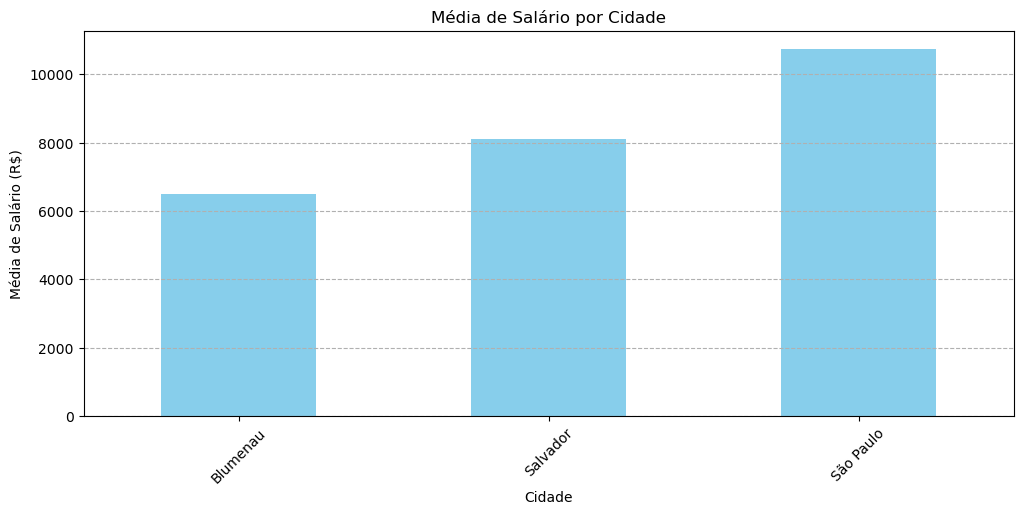

In [87]:
# Gráfico de Barras: Média de Salário por Cidade
media_salario_cidade.plot(kind ='bar', figsize = (12, 5), color = 'skyblue')

# Adicionando título e rótulo
plt.title('Média de Salário por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Média de Salário (R$)')
plt.xticks(rotation = 45)
plt.grid(axis = 'y', linestyle = '--')

# Mostrar o gráfico
plt.show()

In [88]:
# Contagem de registros (funcionários) por cidade
contagem_cidade = df_init['Cidade'].value_counts()

In [89]:
type(contagem_cidade)

pandas.core.series.Series

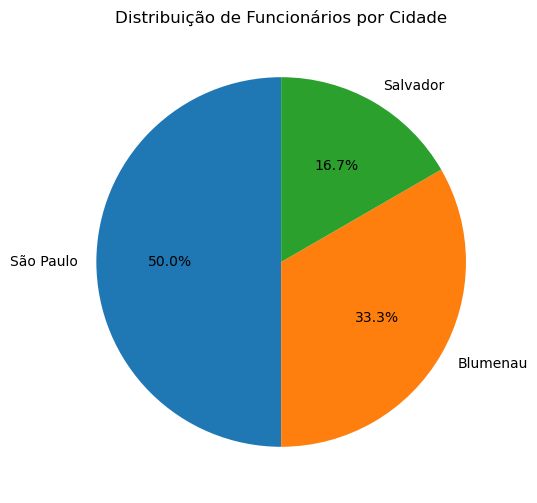

In [90]:
# Gráfico de Pizza: Contagem de funcionários por cidade
contagem_cidade.plot(kind='pie', autopct= '%1.1f%%', figsize = (6, 6), startangle = 90)
plt.title('Distribuição de Funcionários por Cidade')
plt.ylabel('') # Remove o rótulo do eixo y
plt.show()

### Fim